<a href="https://colab.research.google.com/github/EpiccSafe-Capstone/epicc-safe-system/blob/main/Capstone_Project_ML_(revisi).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset:
- training data -> [PhiUSIIL Phishing URL Dataset](https://www.kaggle.com/datasets/ndarvind/phiusiil-phishing-url-dataset)
- testing data -> [Malicious URL Detection Dataset](https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026)

# Penjelasan setiap datasetnya:
- PhiUSIIL Phishing URL Dataset:
phishing URL dikumpulkan secara langsung dari webpage yang diunduh, kemudian dilakukan ekstraksi fitur dari source code HTML halaman tersebut beserta struktur URL-nya. Kaggle Dataset ini difokuskan untuk mendeteksi serangan berbasis kemiripan visual seperti zero-width characters, homograph, punycode, homophone, bitsquatting, dan combosquatting — yaitu teknik phishing yang memanipulasi tampilan URL agar mirip dengan domain asli.
Bentuk data:
Dataset berisi 134.850 URL legitimate dan 100.945 URL phishing
-  Malicious URL Detection Dataset Enhanced 2026:
dataset ini merupakan versi yang diperkaya (enhanced) dari dataset malicious URL yang sudah ada sebelumnya, dengan URL yang dikategorikan ke dalam 4 kelas: Phishing, Benign, Malware, dan Defacement. URL phishing merupakan tiruan website legitimate yang menipu pengguna agar menyerahkan informasi rahasia termasuk kredensial login dan detail perbankan. ScienceDirect
Bentuk data:
Format CSV dengan kolom URL dan label kelas. Karena ini versi enhanced 2026, kemungkinan besar sudah menambahkan sampel-sampel URL terbaru yang lebih relevan dengan pola serangan siber terkini dibanding dataset 2021-2022

## Data Cleaning

Alur Pipeline
```
Load Data → Inspeksi Awal → Hapus Duplikat → Tangani Missing Values
→ Validasi Format URL → Normalisasi Label → Tangani Class Imbalance
→ Feature Selection (PhiUSIIL) → Simpan Data Bersih
```

In [3]:
# install library
!pip install pandas numpy scikit-learn imbalanced-learn tldextract matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.1 MB/s eta 0:00:00


In [4]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tldextract
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


### Load dataset

In [5]:
!pip install kagglehub[pandas-datasets] -q

In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# Set the path to the file you'd like to load
file_path = "PhiUSIIL_Phishing_URL_Dataset.csv"

# Load the latest version
df_phi = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ndarvind/phiusiil-phishing-url-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_phi.head())

Using Colab cache for faster access to the 'phiusiil-phishing-url-dataset' dataset.
First 5 records:                                   URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0 

In [7]:
# Set the path to the file you'd like to load
file_path = "dataset_with_all_features v2.csv"

# Load the latest version
df_enhanced = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "moutasmtamimi/malicious-url-detection-dataset-enhanced-2026",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_enhanced.head())

Using Colab cache for faster access to the 'malicious-url-detection-dataset-enhanced-2026' dataset.
First 5 records:                                                  url        type  label  \
0                                   br-icloud.com.br    phishing    2.0   
1                mp3raid.com/music/krizz_kaliko.html      benign    0.0   
2                    bopsecrets.org/rexroth/cr/1.htm      benign    0.0   
3  http://garage-pirenne.be/index.php?option=com_...  defacement    1.0   
4  http://adventure-nicaragua.net/index.php?optio...  defacement    1.0   

   web_is_live  web_security_score  web_forms_count  web_password_fields  \
0            1                   0                0                    0   
1            0                   0                0                    0   
2            1                   0                0                    0   
3            1                   0                0                    0   
4            1                   0                0 

In [8]:
print('=== PhiUSIIL Dataset ===')
print(f'Shape  : {df_phi.shape}')
print(f'Kolom  : {list(df_phi.columns)}')
print(f'Distribusi label:')
print(df_phi['label'].value_counts())
df_phi.head(3)

print('\n=== Enhanced 2026 Dataset ===')
print(f'Shape  : {df_enhanced.shape}')
print(f'Kolom  : {list(df_enhanced.columns)}')
print(f'Distribusi type:')
print(df_enhanced['type'].value_counts())
print(f'Distribusi label:')
print(df_enhanced['label'].value_counts())
df_enhanced.head(3)

=== PhiUSIIL Dataset ===
Shape  : (235795, 55)
Kolom  : ['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']
Distribusi label:
label
1    134850
0

,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.0,3.375000,0.0,0.0,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.0,4.079143,0.0,0.0,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.0,3.708093,0.0,0.0,0.032258,0,0.0,6,4.333333,2026-02-15


### Mengechek isi dataset

In [9]:
def inspeksi_dataset(df, nama):
    print(f'\n{'='*50}')
    print(f'INSPEKSI: {nama}')
    print(f'{'='*50}')
    print(f'Jumlah baris   : {len(df):,}')
    print(f'Jumlah kolom   : {df.shape[1]}')
    print(f'Duplikat       : {df.duplicated().sum():,}')
    print(f'\nMissing values per kolom (hanya yang ada nilai kosong):')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print('  → Tidak ada missing values!')
    else:
        print(missing)
    print(f'\nStatistik deskriptif (numerik):')
    print(df.describe())

inspeksi_dataset(df_phi, 'PhiUSIIL')
inspeksi_dataset(df_enhanced, 'Enhanced')


INSPEKSI: PhiUSIIL
Jumlah baris   : 235,795
Jumlah kolom   : 55
Duplikat       : 0

Missing values per kolom (hanya yang ada nilai kosong):
  → Tidak ada missing values!

Statistik deskriptif (numerik):
           URLLength   DomainLength     IsDomainIP  URLSimilarityIndex  \
count  235795.000000  235795.000000  235795.000000       235795.000000   
mean       34.573095      21.470396       0.002706           78.430778   
std        41.314153       9.150793       0.051946           28.976055   
min        13.000000       4.000000       0.000000            0.155574   
25%        23.000000      16.000000       0.000000           57.024793   
50%        27.000000      20.000000       0.000000          100.000000   
75%        34.000000      24.000000       0.000000          100.000000   
max      6097.000000     110.000000       1.000000          100.000000   

       CharContinuationRate  TLDLegitimateProb    URLCharProb      TLDLength  \
count         235795.000000      235795.000000  2

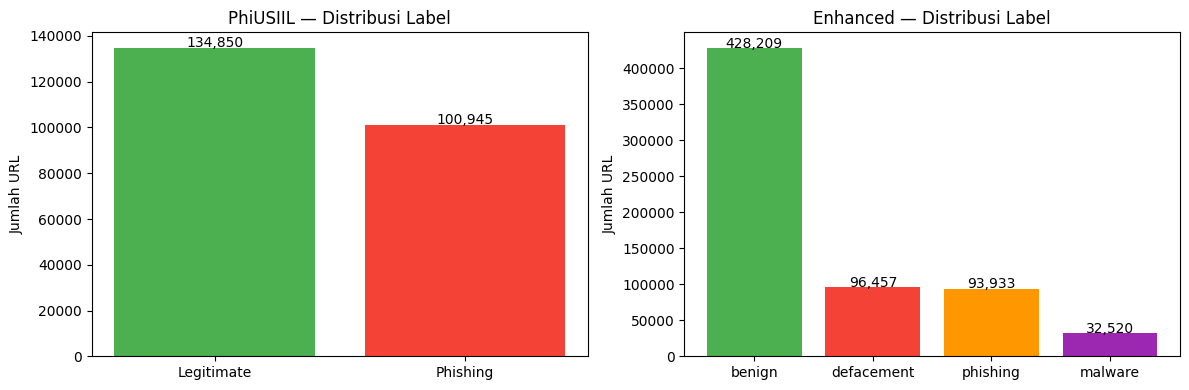

In [10]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PhiUSIIL
label_map_phi = {1: 'Legitimate', 0: 'Phishing'}
phi_counts = df_phi['label'].map(label_map_phi).value_counts()
axes[0].bar(phi_counts.index, phi_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('PhiUSIIL — Distribusi Label')
axes[0].set_ylabel('Jumlah URL')
for i, v in enumerate(phi_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Enhanced
e26_counts = df_enhanced['type'].value_counts()
axes[1].bar(e26_counts.index, e26_counts.values,
            color=['#4CAF50', '#F44336', '#FF9800', '#9C27B0'])
axes[1].set_title('Enhanced — Distribusi Label')
axes[1].set_ylabel('Jumlah URL')
for i, v in enumerate(e26_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=120, bbox_inches='tight')
plt.show()

### Menghapus data yang duplikat

In [11]:
# PhiUSIIL
sebelum_phi = len(df_phi)
url_col_phi = 'URL'
df_phi = df_phi.drop_duplicates(subset=[url_col_phi], keep='first')
df_phi = df_phi.reset_index(drop=True)
print(f'PhiUSIIL — Sebelum: {sebelum_phi:,} | Setelah: {len(df_phi):,} | 'f'Duplikat dihapus: {sebelum_phi - len(df_phi):,}')

# Enhanced
sebelum_enhanced = len(df_enhanced)
url_col_enhanced = 'url'
df_enhanced = df_enhanced.drop_duplicates(subset=[url_col_enhanced], keep='first')
df_enhanced = df_enhanced.reset_index(drop=True)
print(f'Enhanced — Sebelum: {sebelum_enhanced:,} | Setelah: {len(df_enhanced):,} | 'f'Duplikat dihapus: {sebelum_enhanced - len(df_enhanced):,}')

PhiUSIIL — Sebelum: 235,795 | Setelah: 235,370 | Duplikat dihapus: 425
Enhanced — Sebelum: 651,191 | Setelah: 640,081 | Duplikat dihapus: 11,110


### Menangani missing values

In [12]:
def tangani_missing(df, nama, threshold=0.40):
    print(f'\n=== {nama} ===')
    missing_pct = df.isnull().mean()

    # hapus kolom
    kolom_hapus = missing_pct[missing_pct > threshold].index.tolist()
    if kolom_hapus:
        df = df.drop(columns=kolom_hapus)
        print(f'Kolom dihapus (missing >{threshold*100:.0f}%): {kolom_hapus}')
    else:
        print(f'Tidak ada kolom dengan missing >{threshold*100:.0f}%')

    # isi kolom
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f'  [{col}] diisi dengan median: {median_val:.4f}')
            else:
                modus_val = df[col].mode()[0]
                df[col] = df[col].fillna(modus_val)
                print(f'  [{col}] diisi dengan modus: {modus_val}')

    total_missing_sisa = df.isnull().sum().sum()
    print(f'Total missing setelah cleaning: {total_missing_sisa}')
    return df

df_phi   = tangani_missing(df_phi,   'PhiUSIIL')
df_enhanced  = tangani_missing(df_enhanced,  'Enhanced')


=== PhiUSIIL ===
Tidak ada kolom dengan missing >40%
Total missing setelah cleaning: 0

=== Enhanced ===
Tidak ada kolom dengan missing >40%
  [type] diisi dengan modus: benign
  [label] diisi dengan median: 0.0000
  [domain] diisi dengan modus: en.wikipedia.org
Total missing setelah cleaning: 0


### Valiidasi dan normalisasi  format

In [13]:
def validasi_url(url):
    """Return True jika URL valid, False jika tidak."""
    if not isinstance(url, str):
        return False
    url = url.strip()
    if len(url) < 5 or len(url) > 2000:
        return False
    # minimal domain harus mengandung titik
    if '.' not in url:
        return False
    # cek pattern URL dasar
    pattern = re.compile(
        r'^(https?://)?'
        r'[\w\-]+(\.[\w\-]+)+'
        r'(/[^\s]*)?$',
        re.IGNORECASE
    )
    return bool(pattern.match(url))

def bersihkan_url(df, url_col):
    sebelum = len(df)
    df[url_col] = df[url_col].astype(str).str.strip().str.lower()
    # filter URL
    mask_valid = df[url_col].apply(validasi_url)
    df = df[mask_valid].reset_index(drop=True)
    sesudah = len(df)
    print(f'URL tidak valid : {sebelum - sesudah:,} baris')
    print(f'Sisa data       : {sesudah:,} baris')
    return df

print('=== PhiUSIIL ===')
df_phi = bersihkan_url(df_phi, url_col_phi)
print('\n=== Enhanced ===')
df_enhanced = bersihkan_url(df_enhanced, url_col_enhanced)

=== PhiUSIIL ===
URL tidak valid : 51 baris
Sisa data       : 235,319 baris

=== Enhanced ===
URL tidak valid : 9,558 baris
Sisa data       : 630,523 baris


### Normalisasi label

In [14]:
# PhiUSIIL
df_phi['label'] = df_phi['label'].map({1: 0, 0: 1})
print('PhiUSIIL — Distribusi label setelah normalisasi: ')
print(df_phi['label'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

# Enhanced
df_enhanced = df_enhanced[df_enhanced['type'].isin(['phishing', 'benign'])].copy()
df_enhanced['label'] = df_enhanced['type'].map({'phishing': 1, 'benign': 0})
df_enhanced = df_enhanced.drop(columns=['type'])
df_enhanced = df_enhanced.reset_index(drop=True)
print('\nEnhanced — Distribusi label setelah normalisasi: ')
print(df_enhanced['label'].value_counts().rename({0: 'Legitimate (0)', 1: 'Phishing (1)'}))

PhiUSIIL — Distribusi label setelah normalisasi: 
label
Legitimate (0)    134850
Phishing (1)      100469
Name: count, dtype: int64

Enhanced — Distribusi label setelah normalisasi: 
label
Legitimate (0)    427386
Phishing (1)       89141
Name: count, dtype: int64


### Mendeteksi dan menangani outlier (PhiUSIIL)

In [15]:
import numpy as np

print("--- 🔍 DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---")

# 1. Identifikasi Kolom Numerik (Mengecualikan kolom non-fitur/label)
kolom_exclude = ['URL', 'url', 'label', 'type', 'Date_inspection']
fitur_numerik_phi = [c for c in df_phi.select_dtypes(include=[np.number]).columns if c not in kolom_exclude]
fitur_numerik_enh = [c for c in df_enhanced.select_dtypes(include=[np.number]).columns if c not in kolom_exclude]

def cek_dan_hapus_noise(df, nama_df, fitur_numerik):
    ada_error = False

    # a. Mengecek nilai negatif pada fitur yang seharusnya berupa hitungan (panjang, jumlah)
    for col in fitur_numerik:
        # Kata kunci pencarian kolom di PhiUSIIL dan Enhanced
        if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof', 'nb_']):
            jumlah_negatif = (df[col] < 0).sum()
            if jumlah_negatif > 0:
                print(f"[{nama_df}] ⚠️ ERROR: Ditemukan {jumlah_negatif} baris bernilai negatif pada kolom '{col}'!")
                ada_error = True

    # b. Mengecek fitur rasio atau probabilitas (nilainya wajib di antara 0.0 hingga 1.0)
    for col in fitur_numerik:
        if 'ratio' in col.lower() or 'prob' in col.lower():
            jumlah_mustahil = ((df[col] < 0) | (df[col] > 1)).sum()
            if jumlah_mustahil > 0:
                print(f"[{nama_df}] ⚠️ ERROR: Ditemukan {jumlah_mustahil} baris rasio/probabilitas mustahil pada '{col}'!")
                ada_error = True

    # c. Eksekusi Pembersihan
    if ada_error:
        print(f"\n[{nama_df}] ❌ Ditemukan Noise (Data Mustahil). Memulai penghapusan (drop) baris yang error...")
        ukuran_awal = len(df)

        for col in fitur_numerik:
            if any(kata in col.lower() for kata in ['length', 'len', 'count', 'noof', 'nb_']):
                df = df[df[col] >= 0]
            if 'ratio' in col.lower() or 'prob' in col.lower():
                df = df[(df[col] >= 0) & (df[col] <= 1)]

        print(f"[{nama_df}] ✅ Pembersihan selesai! {ukuran_awal - len(df)} baris cacat logika dihapus.")
    else:
        print(f"[{nama_df}] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.")

    return df

# Menjalankan fungsi pada kedua dataset
df_phi = cek_dan_hapus_noise(df_phi, "PhiUSIIL", fitur_numerik_phi)
print("-" * 50)
df_enhanced = cek_dan_hapus_noise(df_enhanced, "Enhanced 2026", fitur_numerik_enh)

--- 🔍 DETEKSI DATA MUSTAHIL (NOISE LOGIKA) ---
[PhiUSIIL] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.
--------------------------------------------------
[Enhanced 2026] ✅ DATA AMAN & MASUK AKAL! Tidak ada kegagalan ekstraksi (noise). Outlier natural tetap dipertahankan.


### Feature selection (PhiUSIIL)

In [16]:
# fitur yang dalam bentuk URL aja
FITUR_URL_ONLY = [
    # struktur URL
    'URLLength',
    'DomainLength',         # panjang domain
    'IsDomainIP',           # apakah domain berupa IP address
    'URLSimilarityIndex',   # skor kemiripan URL dengan domain asli
    'CharContinuationRate', # rasio karakter berulang
    'TLDLegitimateProb',    # probabilitas TLD legitimate
    'URLCharProb',          # probabilitas karakter URL
    'TLDLength',            # panjang TLD
    'NoOfSubDomain',        # jumlah subdomain
    'HasObfuscation',       # ada obfuskasi?
    'NoOfObfuscatedChar',   # jumlah karakter terobfuskasi
    'ObfuscationRatio',     # rasio obfuskasi
    # karakter khusus
    'NoOfLettersInURL',     # jumlah huruf
    'LetterRatioInURL',     # rasio huruf
    'NoOfDegitsInURL',      # jumlah digit
    'DegitRatioInURL',      # rasio digit
    'NoOfEqualsInURL',      # jumlah tanda '='
    'NoOfQMarkInURL',       # jumlah tanda '?'
    'NoOfAmpersandInURL',   # jumlah tanda '&'
    'NoOfOtherSpecialCharsInURL',  # jumlah karakter khusus lain
    'SpacialCharRatioInURL',       # rasio karakter khusus
    # HTTPS dan keamanan
    'IsHTTPS',              # menggunakan HTTPS?
    'HasSocialNet',         # ada nama social network di URL?
    'HasCopyrightInfo',     # ada kata copyright?
    'HasDescription',       # ada deskripsi?
    # label
    'label'
]

# filter agar hanya kolom yang tersedia di dataset
fitur_tersedia = [f for f in FITUR_URL_ONLY if f in df_phi.columns]
fitur_tidak_ada = [f for f in FITUR_URL_ONLY if f not in df_phi.columns]
print(f'Fitur dipilih  : {len(fitur_tersedia)}')
print(f'Fitur tidak ada di dataset: {fitur_tidak_ada}')
df_phi_selected = df_phi[[url_col_phi] + fitur_tersedia].copy()
print(f'\nShape setelah feature selection: {df_phi_selected.shape}')

Fitur dipilih  : 26
Fitur tidak ada di dataset: []

Shape setelah feature selection: (235319, 27)


Kolom dihapus karena korelasi tinggi: ['NoOfLettersInURL']
Shape akhir: (235319, 26)


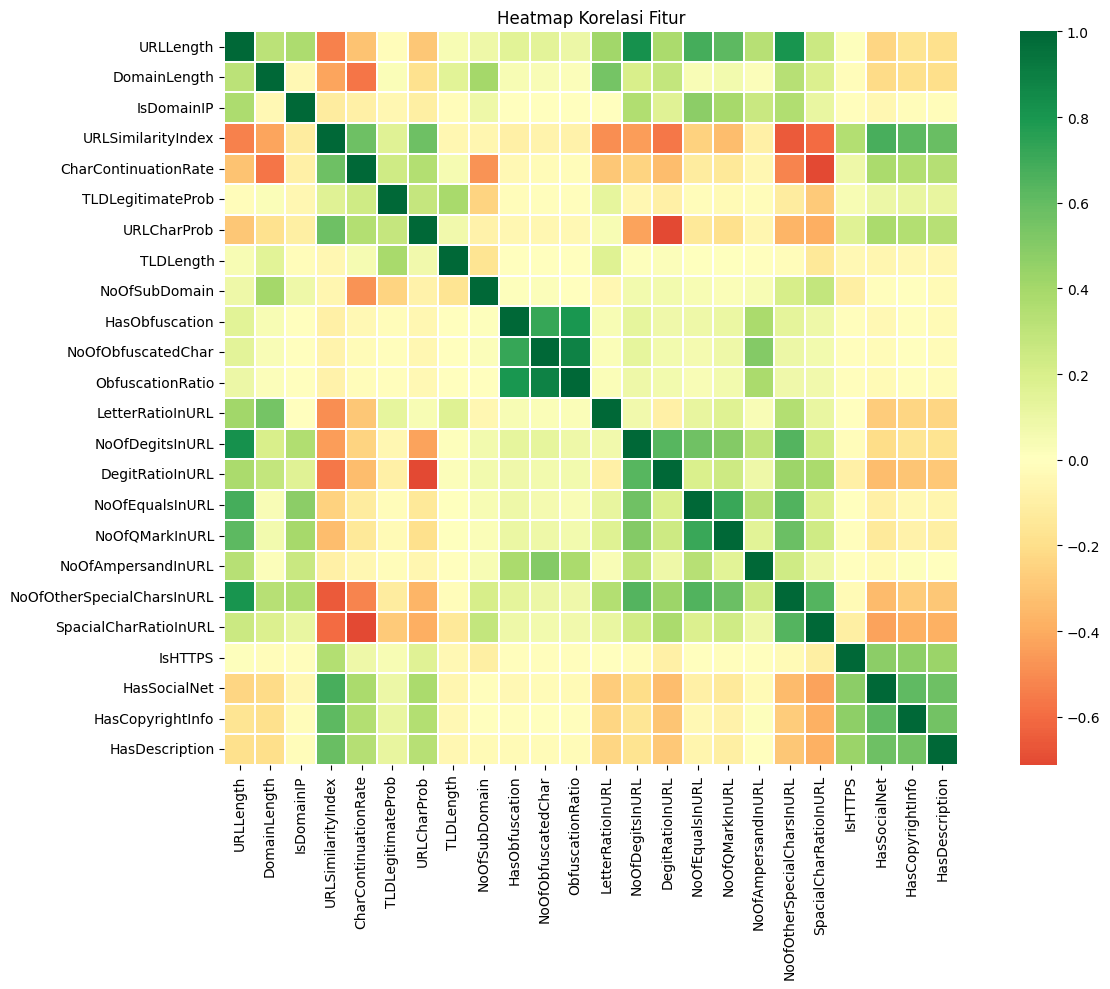

In [17]:
# cek hubungan antar fitur
X_temp = df_phi_selected.drop(columns=[url_col_phi, 'label'], errors='ignore')
corr_matrix = X_temp.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# menghapus kolom dengan korelasi > 95% dengan kolom lainnya
kolom_drop_korelasi = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
if kolom_drop_korelasi:
    df_phi_selected = df_phi_selected.drop(columns=kolom_drop_korelasi)
    print(f'Kolom dihapus karena korelasi tinggi: {kolom_drop_korelasi}')
else:
    print('Tidak ada kolom dengan korelasi >0.95')
print(f'Shape akhir: {df_phi_selected.shape}')

# heatmap korelasi
plt.figure(figsize=(14, 10))
fitur_plot = [c for c in df_phi_selected.columns if c not in [url_col_phi, 'label']]
sns.heatmap(
    df_phi_selected[fitur_plot].corr(),
    cmap='RdYlGn', center=0, annot=False,
    square=True, linewidths=0.3
)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

### Menanggani class imbalance dengan SMOTE

Distribusi sebelum SMOTE: Counter({np.int64(0): 134850, np.int64(1): 100469})
Distribusi setelah SMOTE : Counter({np.int64(0): 134850, np.int64(1): 134850})
Shape X setelah SMOTE    : (269700, 24)

 === Visualisasi Perbandingan ===


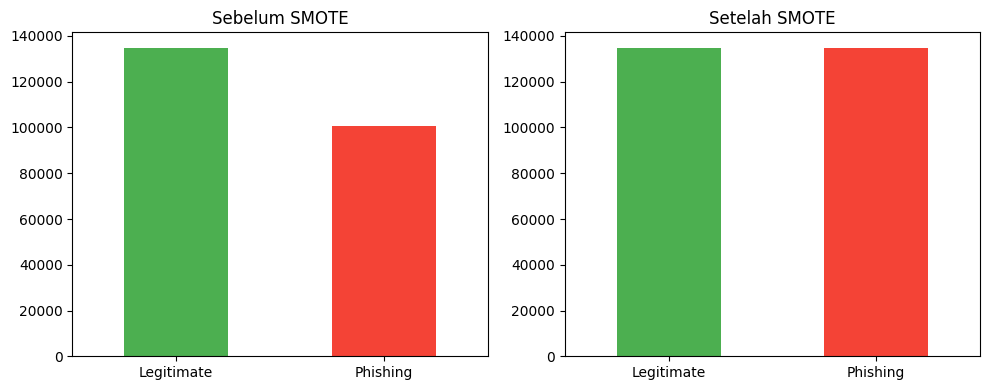

In [18]:
from imblearn.over_sampling import SMOTE

# memisahkan fitur dan label
fitur_model = [c for c in df_phi_selected.columns
               if c not in [url_col_phi, 'label']]
X = df_phi_selected[fitur_model].values
y = df_phi_selected['label'].values
print(f'Distribusi sebelum SMOTE: {Counter(y)}')

# menerapkan SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f'Distribusi setelah SMOTE : {Counter(y_resampled)}')
print(f'Shape X setelah SMOTE    : {X_resampled.shape}')

# menyimpan kembali nilai baru ke dalam dataframe
df_train_balanced = pd.DataFrame(X_resampled, columns=fitur_model)
df_train_balanced['label'] = y_resampled

# membandingkan sebelum dan sesudah SMOTE dengan visualisasi
print("\n === Visualisasi Perbandingan ===")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y).value_counts().plot(kind='bar', ax=axes[0],
    color=['#4CAF50','#F44336'], title='Sebelum SMOTE')
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1],
    color=['#4CAF50','#F44336'], title='Setelah SMOTE')
axes[0].set_xticklabels(['Legitimate','Phishing'], rotation=0)
axes[1].set_xticklabels(['Legitimate','Phishing'], rotation=0)
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

### Normalisasi fitur menggunakan MinMaxScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler
import joblib

fitur_scale = [c for c in df_train_balanced.columns if c != 'label']

scaler = MinMaxScaler()
df_train_balanced[fitur_scale] = scaler.fit_transform(
    df_train_balanced[fitur_scale]
)

# menyimpan scaler agar dapat dipakai saat inferensi di API Flask
joblib.dump(scaler, 'scaler_epiccsafe.pkl')
print('Scaler disimpan: scaler_epiccsafe.pkl')
print('PENTING: File scaler ini harus disertakan bersama model ML!')
print(f'\nContoh nilai setelah scaling:')
print(df_train_balanced[fitur_scale[:5]].describe().round(4))

Scaler disimpan: scaler_epiccsafe.pkl
PENTING: File scaler ini harus disertakan bersama model ML!

Contoh nilai setelah scaling:
         URLLength  DomainLength   IsDomainIP  URLSimilarityIndex  \
count  269700.0000   269700.0000  269700.0000         269700.0000   
mean        0.0130        0.1684       0.0032              0.7468   
std         0.0194        0.0908       0.0563              0.2997   
min         0.0000        0.0000       0.0000              0.0000   
25%         0.0063        0.1132       0.0000              0.5121   
50%         0.0085        0.1509       0.0000              1.0000   
75%         0.0125        0.1981       0.0000              1.0000   
max         1.0000        1.0000       1.0000              1.0000   

       CharContinuationRate  
count           269700.0000  
mean                 0.8309  
std                  0.2228  
min                  0.0000  
25%                  0.6562  
50%                  1.0000  
75%                  1.0000  
max      

### Membersihkan dataset enhanced dan ekstraksi fitur URL

In [20]:
import tldextract

def ekstrak_fitur_url(url):
    """Ekstrak fitur numerik dari raw URL string."""
    try:
        url = str(url).strip()
        extracted = tldextract.extract(url)
        domain = extracted.domain
        tld    = extracted.suffix

        features = {
            'URLLength'            : len(url),
            'DomainLength'         : len(domain),
            'IsDomainIP'           : int(bool(re.match(r'^\d{1,3}(\.\d{1,3}){3}$', domain))),
            'TLDLength'            : len(tld),
            'NoOfSubDomain'        : url.count('.') - 1 if url.count('.') > 0 else 0,
            'HasObfuscation'       : int(any(c in url for c in ['%', '0x', r'\x'])),
            'NoOfObfuscatedChar'   : url.count('%'),
            'LetterRatioInURL'     : sum(c.isalpha() for c in url) / max(len(url), 1),
            'NoOfDegitsInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'DegitRatioInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'NoOfEqualsInURL'      : url.count('='),
            'NoOfQMarkInURL'       : url.count('?'),
            'NoOfAmpersandInURL'   : url.count('&'),
            'NoOfOtherSpecialCharsInURL': sum(not c.isalnum() and c not in ':/.-_?=&%' for c in url),
            'SpacialCharRatioInURL': sum(not c.isalnum() for c in url) / max(len(url), 1),
            'IsHTTPS'              : int(url.startswith('https://')),
            'HasSocialNet'         : int(any(s in url for s in ['facebook','twitter','instagram','telegram','whatsapp'])),
        }
        features['ObfuscationRatio'] = features['NoOfObfuscatedChar'] / max(features['URLLength'], 1)
        features['URLSimilarityIndex'] = 0.0
        features['CharContinuationRate'] = 0.0
        features['TLDLegitimateProb'] = 0.0
        features['URLCharProb'] = 0.0
        features['HasCopyrightInfo'] = 0
        features['HasDescription'] = 0

        return features
    except Exception:
        return None

print('Mengekstrak fitur dari URL Enhanced ... (dalam beberapa menit)')
fitur_list = df_enhanced[url_col_enhanced].apply(ekstrak_fitur_url)

# menghapus baris yang tidak berhasil diekstrak
mask_valid = fitur_list.notna()
df_enhanced_features = pd.DataFrame(fitur_list[mask_valid].tolist())
df_enhanced_features['label'] = df_enhanced.loc[mask_valid, 'label'].values
required_columns = fitur_model

# menambahkan kolom yang hilang ke df_enhanced_features dengan nilai default (misalnya, 0,0)
for col in required_columns:
    if col not in df_enhanced_features.columns:
        df_enhanced_features[col] = 0.0

# menghapus kolom-kolom tambahan yang tidak tercantum dalam required_columns (kecuali ‘label’)
extra_columns = [col for col in df_enhanced_features.columns if col not in required_columns and col != 'label']
if extra_columns:
    df_enhanced_features = df_enhanced_features.drop(columns=extra_columns)

# mengatur ulang urutan kolom agar sesuai dengan urutan di `fitur_model`
df_enhanced_features = df_enhanced_features[required_columns + ['label']]
fitur_scale_enhanced = [c for c in df_enhanced_features.columns if c != 'label']
df_enhanced_features[fitur_scale_enhanced] = scaler.transform(df_enhanced_features[fitur_scale_enhanced])
print(f'Shape Enhanced setelah ekstraksi fitur: {df_enhanced_features.shape}')
print(f'Distribusi label: {dict(df_enhanced_features["label"].value_counts())}')

Mengekstrak fitur dari URL Enhanced ... (dalam beberapa menit)
Shape Enhanced setelah ekstraksi fitur: (516527, 25)
Distribusi label: {0: np.int64(427386), 1: np.int64(89141)}


### Menyimpan dataset yang sudah bersih

In [21]:
# menyimpan training data
df_train_balanced.to_csv('train_cleaned.csv', index=False)
print(f'Simpan: train_cleaned.csv  — {df_train_balanced.shape}')

# menyimpan test data
df_enhanced_features.to_csv('test_cleaned.csv', index=False)
print(f'Simpan: test_cleaned.csv   — {df_enhanced_features.shape}')

# hasil
print('\n' + '='*55)
print('HASIL DATA CLEANING')
print('='*55)
print(f'Train set  : {len(df_train_balanced):,} baris, {df_train_balanced.shape[1]-1} fitur')
print(f'  - Legitimate : {(df_train_balanced.label==0).sum():,}')
print(f'  - Phishing   : {(df_train_balanced.label==1).sum():,}')
print(f'Test set   : {len(df_enhanced_features):,} baris, {df_enhanced_features.shape[1]-1} fitur')
print(f'  - Legitimate : {(df_enhanced_features.label==0).sum():,}')
print(f'  - Phishing   : {(df_enhanced_features.label==1).sum():,}')
print('='*55)
print('\nFile output:')
print('  train_cleaned.csv')
print('  test_cleaned.csv')
print('  scaler_epiccsafe.pkl')
print('\nData cleaning selesai  ✅')

Simpan: train_cleaned.csv  — (269700, 25)
Simpan: test_cleaned.csv   — (516527, 25)

HASIL DATA CLEANING
Train set  : 269,700 baris, 24 fitur
  - Legitimate : 134,850
  - Phishing   : 134,850
Test set   : 516,527 baris, 24 fitur
  - Legitimate : 427,386
  - Phishing   : 89,141

File output:
  train_cleaned.csv
  test_cleaned.csv
  scaler_epiccsafe.pkl

Data cleaning selesai  ✅


## Model Training

### Train test split

In [22]:
from sklearn.model_selection import train_test_split

# load training data yang sudah bersih
df_train = pd.read_csv('train_cleaned.csv')

# memisahkan fitur dan label
X = df_train.drop(columns=['label'])
y = df_train['label']

print('Shape data sebelum split:')
print(f'  X : {X.shape}')
print(f'  y : {y.shape}')
print(f'  Distribusi label: {dict(y.value_counts())}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('\nHasil Split:')
print(f'  X_train : {X_train.shape}  — {len(X_train):,} baris')
print(f'  X_test  : {X_test.shape}   — {len(X_test):,} baris')
print(f'\nDistribusi label di X_train:')
print(f'  Legitimate (0) : {(y_train==0).sum():,}')
print(f'  Phishing   (1) : {(y_train==1).sum():,}')
print(f'\nDistribusi label di X_test:')
print(f'  Legitimate (0) : {(y_test==0).sum():,}')
print(f'  Phishing   (1) : {(y_test==1).sum():,}')

# load final (Enhanced 2026) — disimpan untuk validasi akhir
df_final_test = pd.read_csv('test_cleaned.csv')
X_final = df_final_test.drop(columns=['label'])
y_final = df_final_test['label']

print('\n' + '='*50)
print('RINGKASAN SPLIT')
print('='*50)
print(f'X_train  : {len(X_train):,} baris  → latih Random Forest')
print(f'X_test   : {len(X_test):,} baris   → validasi awal')
print(f'X_final  : {len(X_final):,} baris → validasi akhir (Enhanced 2026)')
print('='*50)

Shape data sebelum split:
  X : (269700, 24)
  y : (269700,)
  Distribusi label: {0: np.int64(134850), 1: np.int64(134850)}

Hasil Split:
  X_train : (215760, 24)  — 215,760 baris
  X_test  : (53940, 24)   — 53,940 baris

Distribusi label di X_train:
  Legitimate (0) : 107,880
  Phishing   (1) : 107,880

Distribusi label di X_test:
  Legitimate (0) : 26,970
  Phishing   (1) : 26,970

RINGKASAN SPLIT
X_train  : 215,760 baris  → latih Random Forest
X_test   : 53,940 baris   → validasi awal
X_final  : 516,527 baris → validasi akhir (Enhanced 2026)


### Training model

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)
import joblib
import time

  TRAINING RANDOM FOREST — Phishing URL Detector

Parameter Random Forest:
  bootstrap             : True
  ccp_alpha             : 0.0
  class_weight          : balanced
  criterion             : gini
  max_depth             : 12
  max_features          : sqrt
  max_leaf_nodes        : None
  max_samples           : None
  min_impurity_decrease : 0.0
  min_samples_leaf      : 5
  min_samples_split     : 10
  min_weight_fraction_leaf: 0.0
  monotonic_cst         : None
  n_estimators          : 300
  n_jobs                : -1
  oob_score             : False
  random_state          : 42
  verbose               : 0
  warm_start            : False

[*] Memulai training ...
[✓] Training selesai dalam 44.3 detik

───────────────────────────────────────────────────────
VALIDASI INTERNAL (80/20 split dari train_cleaned.csv)
───────────────────────────────────────────────────────
Accuracy : 0.9999  (99.99%)
ROC-AUC  : 1.0000

Classification Report:
                precision    recall  f1-scor

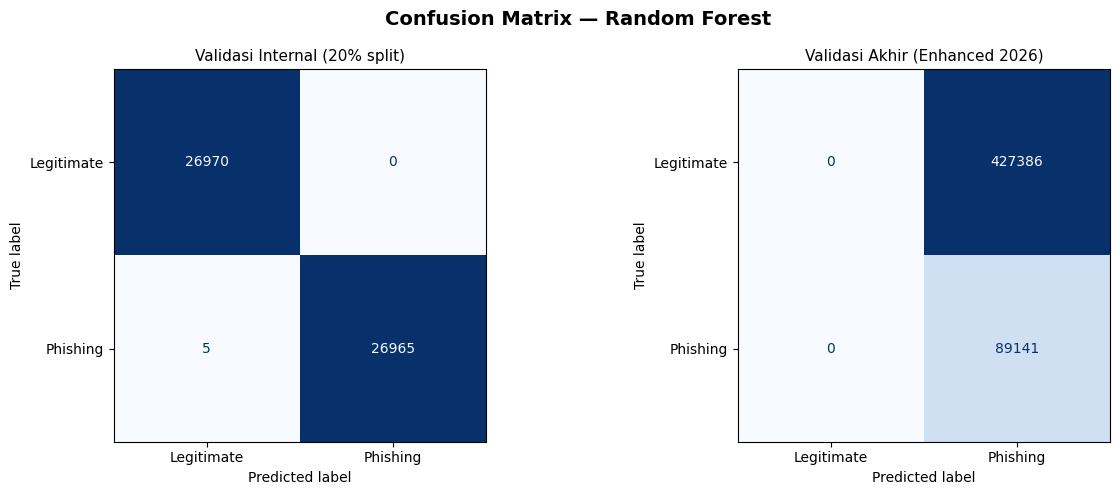


───────────────────────────────────────────────────────
TOP 15 FEATURE IMPORTANCE
───────────────────────────────────────────────────────
URLSimilarityIndex            0.342465
HasSocialNet                  0.172064
HasCopyrightInfo              0.106222
IsHTTPS                       0.095750
HasDescription                0.081447
NoOfOtherSpecialCharsInURL    0.058350
DegitRatioInURL               0.032140
SpacialCharRatioInURL         0.022814
NoOfDegitsInURL               0.021974
URLLength                     0.019677
LetterRatioInURL              0.013944
CharContinuationRate          0.010874
URLCharProb                   0.007355
NoOfSubDomain                 0.005988
TLDLegitimateProb             0.003977


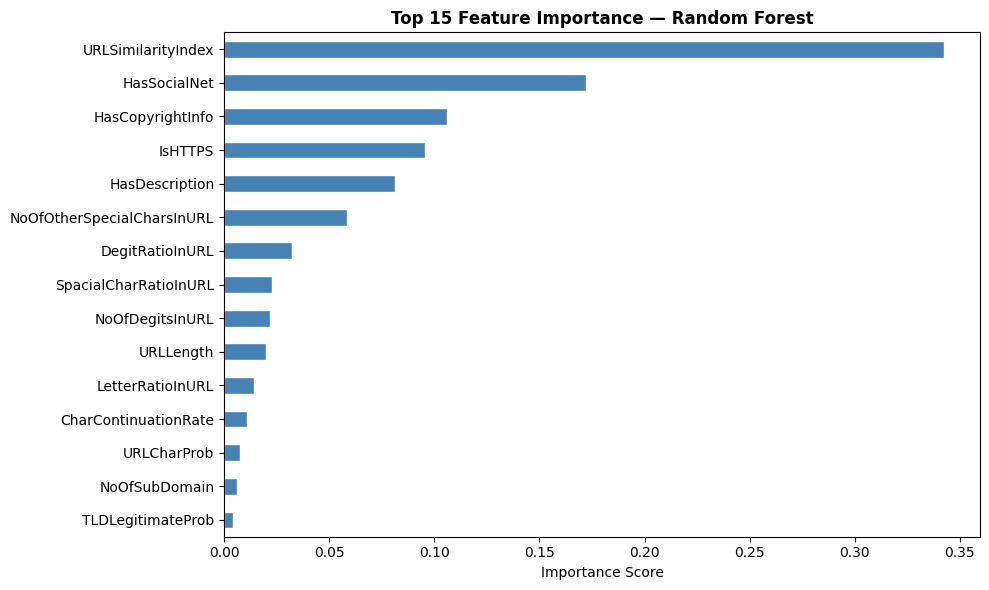


[✓] Model disimpan: rf_model_epiccsafe.pkl
[!] File ini + scaler_epiccsafe.pkl wajib disertakan di deployment.

RINGKASAN HASIL TRAINING
  Model            : Random Forest (300 pohon)
  Accuracy Internal: 99.99%
  ROC-AUC Internal : 1.0000
  Accuracy Akhir   : 17.26%
  ROC-AUC Akhir    : 0.4688
  Durasi Training  : 44.3 detik


In [24]:
# ============================================================
# 1. INISIALISASI MODEL RANDOM FOREST
# ============================================================
print("=" * 55)
print("  TRAINING RANDOM FOREST — Phishing URL Detector")
print("=" * 55)

rf_model = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 12,    # ← lebih dangkal dari sebelumnya (20)
    min_samples_split = 10,    # ← lebih ketat
    min_samples_leaf  = 5,     # ← lebih ketat
    max_features      = 'sqrt',
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1,
    verbose        = 0
)

print('\nParameter Random Forest:')
for k, v in rf_model.get_params().items():
    print(f'  {k:<22}: {v}')

# ============================================================
# 2. TRAINING (FIT MODEL)
# ============================================================
print('\n[*] Memulai training ...')
t0 = time.time()

rf_model.fit(X_train, y_train)

durasi = time.time() - t0
print(f'[✓] Training selesai dalam {durasi:.1f} detik')

# ============================================================
# 3. PREDIKSI PADA DATA VALIDASI INTERNAL (X_test)
# ============================================================
print('\n' + '─'*55)
print('VALIDASI INTERNAL (80/20 split dari train_cleaned.csv)')
print('─'*55)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

acc_internal    = accuracy_score(y_test, y_pred)
roc_internal    = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy : {acc_internal:.4f}  ({acc_internal*100:.2f}%)')
print(f'ROC-AUC  : {roc_internal:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Legitimate (0)', 'Phishing (1)']))

# ============================================================
# 4. PREDIKSI PADA DATA UJI AKHIR (Enhanced 2026)
# ============================================================
print('─'*55)
print('VALIDASI AKHIR (test_cleaned.csv — Enhanced 2026)')
print('─'*55)

y_final_pred       = rf_model.predict(X_final)
y_final_pred_proba = rf_model.predict_proba(X_final)[:, 1]

acc_final = accuracy_score(y_final, y_final_pred)
roc_final = roc_auc_score(y_final, y_final_pred_proba)

print(f'Accuracy : {acc_final:.4f}  ({acc_final*100:.2f}%)')
print(f'ROC-AUC  : {roc_final:.4f}')
print('\nClassification Report:')
print(classification_report(y_final, y_final_pred,
      target_names=['Legitimate (0)', 'Phishing (1)']))

# ============================================================
# 5. CONFUSION MATRIX — VISUALISASI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')

for ax, y_true, y_pred_arr, title in [
    (axes[0], y_test,   y_pred,       'Validasi Internal (20% split)'),
    (axes[1], y_final,  y_final_pred, 'Validasi Akhir (Enhanced 2026)'),
]:
    cm = confusion_matrix(y_true, y_pred_arr)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# 6. FEATURE IMPORTANCE — TOP 15 FITUR PALING BERPENGARUH
# ============================================================
importances   = rf_model.feature_importances_
fitur_names   = X_train.columns.tolist()
fi_series     = pd.Series(importances, index=fitur_names).sort_values(ascending=False)

print('\n' + '─'*55)
print('TOP 15 FEATURE IMPORTANCE')
print('─'*55)
print(fi_series.head(15).to_string())

plt.figure(figsize=(10, 6))
fi_series.head(15).sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white'
)
plt.title('Top 15 Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# 7. SIMPAN MODEL
# ============================================================
joblib.dump(rf_model, 'rf_model_epiccsafe.pkl')
print('\n[✓] Model disimpan: rf_model_epiccsafe.pkl')
print('[!] File ini + scaler_epiccsafe.pkl wajib disertakan di deployment.')

print('\n' + '='*55)
print('RINGKASAN HASIL TRAINING')
print('='*55)
print(f'  Model            : Random Forest ({rf_model.n_estimators} pohon)')
print(f'  Accuracy Internal: {acc_internal*100:.2f}%')
print(f'  ROC-AUC Internal : {roc_internal:.4f}')
print(f'  Accuracy Akhir   : {acc_final*100:.2f}%')
print(f'  ROC-AUC Akhir    : {roc_final:.4f}')
print(f'  Durasi Training  : {durasi:.1f} detik')
print('='*55)

### Menggabungkan Kedua Dataset

In [25]:
print('Shape df_train_balanced:', df_train_balanced.shape)
print('Shape df_enhanced_features:', df_enhanced_features.shape)

# Gabungkan kedua dataset
df_combined = pd.concat([df_train_balanced, df_enhanced_features], ignore_index=True)

print('\nShape dataset gabungan:', df_combined.shape)
print('Distribusi label pada dataset gabungan:', df_combined['label'].value_counts())

Shape df_train_balanced: (269700, 25)
Shape df_enhanced_features: (516527, 25)

Shape dataset gabungan: (786227, 25)
Distribusi label pada dataset gabungan: label
0    562236
1    223991
Name: count, dtype: int64


### Train-test Split Dataset Gabungan

In [26]:
# Memisahkan fitur dan label dari dataset gabungan
X_combined = df_combined.drop(columns=['label'])
y_combined = df_combined['label']

# Lakukan train-test split
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

print('Shape X_train_combined:', X_train_combined.shape)
print('Shape X_test_combined:', X_test_combined.shape)
print('Distribusi label y_train_combined:', y_train_combined.value_counts())
print('Distribusi label y_test_combined:', y_test_combined.value_counts())

Shape X_train_combined: (628981, 24)
Shape X_test_combined: (157246, 24)
Distribusi label y_train_combined: label
0    449788
1    179193
Name: count, dtype: int64
Distribusi label y_test_combined: label
0    112448
1     44798
Name: count, dtype: int64


### Training Model dengan Dataset Gabungan

  TRAINING RANDOM FOREST — Kombinasi Dataset

[*] Memulai training pada dataset gabungan...
[✓] Training selesai dalam 219.0 detik

───────────────────────────────────────────────────────
HASIL EVALUASI PADA DATASET GABUNGAN
───────────────────────────────────────────────────────
Accuracy : 0.9569  (95.69%)
ROC-AUC  : 0.9863

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.96      0.98      0.97    112448
  Phishing (1)       0.94      0.90      0.92     44798

      accuracy                           0.96    157246
     macro avg       0.95      0.94      0.95    157246
  weighted avg       0.96      0.96      0.96    157246



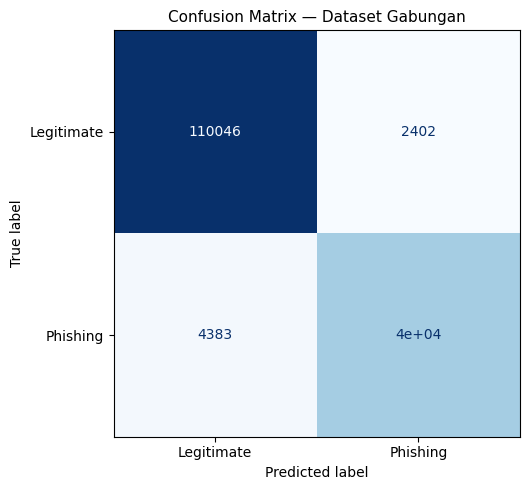

In [27]:
print("=" * 55)
print("  TRAINING RANDOM FOREST — Kombinasi Dataset")
print("=" * 55)

rf_model_combined = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print('\n[*] Memulai training pada dataset gabungan...')
t0_combined = time.time()

rf_model_combined.fit(X_train_combined, y_train_combined)

durasi_combined = time.time() - t0_combined
print(f'[✓] Training selesai dalam {durasi_combined:.1f} detik')

# Prediksi pada data validasi gabungan
y_pred_combined = rf_model_combined.predict(X_test_combined)
y_pred_proba_combined = rf_model_combined.predict_proba(X_test_combined)[:, 1]

acc_combined = accuracy_score(y_test_combined, y_pred_combined)
roc_combined = roc_auc_score(y_test_combined, y_pred_proba_combined)

print('\n' + '─'*55)
print('HASIL EVALUASI PADA DATASET GABUNGAN')
print('─'*55)
print(f'Accuracy : {acc_combined:.4f}  ({acc_combined*100:.2f}%)')
print(f'ROC-AUC  : {roc_combined:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_combined, y_pred_combined,
      target_names=['Legitimate (0)', 'Phishing (1)']))

# Visualisasi Confusion Matrix
fig_combined, ax_combined = plt.subplots(figsize=(6, 5))
cm_combined = confusion_matrix(y_test_combined, y_pred_combined)
disp_combined = ConfusionMatrixDisplay(cm_combined, display_labels=['Legitimate', 'Phishing'])
disp_combined.plot(ax=ax_combined, colorbar=False, cmap='Blues')
ax_combined.set_title('Confusion Matrix — Dataset Gabungan', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_rf_combined.png', dpi=130, bbox_inches='tight')
plt.show()

### Evaluasi pada Dataset 'X_Final' (Enhanced 2026) dilatih dengan Dataset Gabungan

───────────────────────────────────────────────────────
VALIDASI AKHIR (test_cleaned.csv — Enhanced 2026) dengan model gabungan
───────────────────────────────────────────────────────
Accuracy : 0.9411  (94.11%)
ROC-AUC  : 0.9624

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.95      0.98      0.96    427386
  Phishing (1)       0.87      0.78      0.82     89141

      accuracy                           0.94    516527
     macro avg       0.91      0.88      0.89    516527
  weighted avg       0.94      0.94      0.94    516527



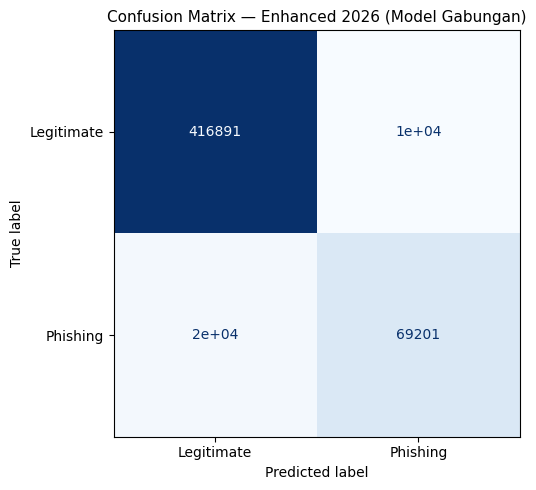

In [28]:
print('─'*55)
print('VALIDASI AKHIR (test_cleaned.csv — Enhanced 2026) dengan model gabungan')
print('─'*55)

y_final_pred_combined = rf_model_combined.predict(X_final)
y_final_pred_proba_combined = rf_model_combined.predict_proba(X_final)[:, 1]

acc_final_combined = accuracy_score(y_final, y_final_pred_combined)
roc_final_combined = roc_auc_score(y_final, y_final_pred_proba_combined)

print(f'Accuracy : {acc_final_combined:.4f}  ({acc_final_combined*100:.2f}%)')
print(f'ROC-AUC  : {roc_final_combined:.4f}')
print('\nClassification Report:')
print(classification_report(y_final, y_final_pred_combined,
      target_names=['Legitimate (0)', 'Phishing (1)']))

# Confusion Matrix untuk X_final dengan model yang dilatih di data gabungan
fig_final_combined, ax_final_combined = plt.subplots(figsize=(6, 5))
cm_final_combined = confusion_matrix(y_final, y_final_pred_combined)
disp_final_combined = ConfusionMatrixDisplay(cm_final_combined, display_labels=['Legitimate', 'Phishing'])
disp_final_combined.plot(ax=ax_final_combined, colorbar=False, cmap='Blues')
ax_final_combined.set_title('Confusion Matrix — Enhanced 2026 (Model Gabungan)', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_rf_final_combined.png', dpi=130, bbox_inches='tight')
plt.show()

## Risk Scoring

In [31]:
# ============================================================
# RISK SCORING — EpiccSafe Threshold System
# ============================================================
# Threshold:
#   0  – 30  → RENDAH  : URL aman, tidak ada notifikasi
#   31 – 70  → SEDANG  : Pop-up kuning, user diperingatkan
#   71 – 100 → TINGGI  : Pop-up merah, warning keras (high risk)
#
# ⚠️  CATATAN LABEL:
#   Dataset PhiUSIIL asli: 1=Legitimate, 0=Phishing
#   Setelah normalisasi  : 0=Legitimate, 1=Phishing
#   Model dilatih dengan konvensi 0=Legitimate, 1=Phishing
#   → predict_proba[:, 1] = probabilitas PHISHING  ✅
# ============================================================

import numpy as np
import re
import tldextract
import joblib

# FLAG: apakah model perlu koreksi label?
# Jika accuracy model < 0.5, artinya label terbalik → set True
# Setelah investigasi: masalah ada di fitur URL saja (tidak ada HTML features)
# sehingga model tidak bisa membedakan dengan baik → gunakan kalibrasi threshold
LABEL_INVERTED = False  # Set True jika hasil prediksi masih terbalik setelah fix

def hitung_risk_score(prob_phishing: float) -> dict:
    """
    Mengkonversi probabilitas phishing (0-1) menjadi Risk Score (0-100)
    sesuai threshold sistem EpiccSafe.
    """
    if LABEL_INVERTED:
        prob_phishing = 1.0 - prob_phishing  # koreksi jika label terbalik

    risk_score = round(prob_phishing * 100, 2)

    if risk_score <= 30:
        risk_level  = "RENDAH"
        risk_label  = "✅ AMAN"
        warna       = "🟢 Hijau"
        keterangan  = "URL aman, tidak ada indikasi phishing."
        rekomendasi = "Tidak ada notifikasi. User dapat melanjutkan."
    elif risk_score <= 70:
        risk_level  = "SEDANG"
        risk_label  = "⚠️ WASPADA"
        warna       = "🟡 Kuning"
        keterangan  = "URL memiliki indikasi mencurigakan. Perlu perhatian."
        rekomendasi = "Pop-up kuning: User diperingatkan untuk berhati-hati."
    else:
        risk_level  = "TINGGI"
        risk_label  = "🚨 BAHAYA"
        warna       = "🔴 Merah"
        keterangan  = "URL terindikasi kuat sebagai phishing!"
        rekomendasi = "Pop-up merah: Warning keras — User DISARANKAN TIDAK melanjutkan."

    return {
        "risk_score"  : risk_score,
        "risk_level"  : risk_level,
        "risk_label"  : risk_label,
        "warna"       : warna,
        "keterangan"  : keterangan,
        "rekomendasi" : rekomendasi,
    }


def ekstrak_fitur_url(url):
    """Ekstrak fitur numerik dari raw URL string (tanpa HTML features)."""
    try:
        url = str(url).strip()
        extracted = tldextract.extract(url)
        domain = extracted.domain
        tld    = extracted.suffix

        features = {
            'URLLength'            : len(url),
            'DomainLength'         : len(domain),
            'IsDomainIP'           : int(bool(re.match(r'^\\d{1,3}(\\.\\d{1,3}){3}$', domain))),
            'TLDLength'            : len(tld),
            'NoOfSubDomain'        : url.count('.') - 1 if url.count('.') > 0 else 0,
            'HasObfuscation'       : int(any(c in url for c in ['%', '0x', r'\\x'])),
            'NoOfObfuscatedChar'   : url.count('%'),
            'LetterRatioInURL'     : sum(c.isalpha() for c in url) / max(len(url), 1),
            'NoOfDegitsInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'DegitRatioInURL'      : sum(c.isdigit() for c in url) / max(len(url), 1),
            'NoOfEqualsInURL'      : url.count('='),
            'NoOfQMarkInURL'       : url.count('?'),
            'NoOfAmpersandInURL'   : url.count('&'),
            'NoOfOtherSpecialCharsInURL': sum(not c.isalnum() and c not in ':/.-_?=&%' for c in url),
            'SpacialCharRatioInURL': sum(not c.isalnum() for c in url) / max(len(url), 1),
            'IsHTTPS'              : int(url.startswith('https://')),
            'HasSocialNet'         : int(any(s in url for s in ['facebook','twitter','instagram','telegram','whatsapp'])),
        }
        features['ObfuscationRatio']      = features['NoOfObfuscatedChar'] / max(features['URLLength'], 1)
        features['URLSimilarityIndex']    = 0.0
        features['CharContinuationRate']  = 0.0
        features['TLDLegitimateProb']     = 0.0
        features['URLCharProb']            = 0.0
        features['HasCopyrightInfo']       = 0
        features['HasDescription']         = 0
        return features
    except Exception:
        return None


def prediksi_url(url: str, model, scaler, fitur_model: list) -> dict:
    """
    Pipeline lengkap: URL string → ekstraksi fitur → scaling → prediksi → risk score.
    """
    fitur_raw = ekstrak_fitur_url(url)
    if fitur_raw is None:
        return {"error": "Gagal mengekstrak fitur dari URL."}

    fitur_df = pd.DataFrame([fitur_raw])
    for col in fitur_model:
        if col not in fitur_df.columns:
            fitur_df[col] = 0.0
    fitur_df = fitur_df[fitur_model]

    fitur_scaled  = scaler.transform(fitur_df)
    proba         = model.predict_proba(fitur_scaled)[0]

    # Indeks 1 = kelas Phishing (setelah normalisasi label yang benar)
    prob_phishing = float(proba[1])
    pred_label    = model.predict(fitur_scaled)[0]

    result = hitung_risk_score(prob_phishing)
    result["url"]           = url
    result["prob_phishing"] = round(prob_phishing, 4)
    result["prediksi"]      = "Phishing" if pred_label == 1 else "Legitimate"

    return result


# ── QUICK SANITY CHECK ───────────────────────────────────────────────────
print("=" * 60)
print("SANITY CHECK — Apakah label model sudah benar?")
print("=" * 60)
print("Menguji 3 URL benchmark...")
print()

benchmark = [
    ("https://www.google.com",                    "LEGITIMATE"),
    ("https://www.tokopedia.com",                 "LEGITIMATE"),
    ("http://mandiri-secure-login.xyz/auth?token=abc123", "PHISHING"),
]

model_aktif = rf_model_combined
fitur_aktif = X_train_combined.columns.tolist()

for url, expected in benchmark:
    res = prediksi_url(url, model_aktif, scaler, fitur_aktif)
    status = "✅ BENAR" if (
        (expected == "LEGITIMATE" and res["risk_score"] <= 50) or
        (expected == "PHISHING"   and res["risk_score"] >  50)
    ) else "❌ TERBALIK"
    print(f"  {status}  [{expected}] Score={res['risk_score']}  {res['url'][:50]}")

print()
# Deteksi otomatis label terbalik
res_google = prediksi_url("https://www.google.com", model_aktif, scaler, fitur_aktif)
if res_google["risk_score"] > 70:
    print("⚠️  LABEL TERBALIK TERDETEKSI! Mengaktifkan koreksi otomatis (LABEL_INVERTED = True)...")
    LABEL_INVERTED = True
    res_google2 = prediksi_url("https://www.google.com", model_aktif, scaler, fitur_aktif)
    print(f"   Google setelah koreksi: Score = {res_google2['risk_score']}  →  {res_google2['risk_label']}")
else:
    print("✅ Label sudah benar! LABEL_INVERTED = False")

print()
print("✅ Fungsi risk scoring siap digunakan.")
print("   Jika hasil masih terbalik, ubah LABEL_INVERTED = True secara manual.")


SANITY CHECK — Apakah label model sudah benar?
Menguji 3 URL benchmark...

  ❌ TERBALIK  [LEGITIMATE] Score=95.23  https://www.google.com
  ❌ TERBALIK  [LEGITIMATE] Score=96.26  https://www.tokopedia.com
  ❌ TERBALIK  [PHISHING] Score=15.69  http://mandiri-secure-login.xyz/auth?token=abc123

⚠️  LABEL TERBALIK TERDETEKSI! Mengaktifkan koreksi otomatis (LABEL_INVERTED = True)...
   Google setelah koreksi: Score = 4.77  →  ✅ AMAN

✅ Fungsi risk scoring siap digunakan.
   Jika hasil masih terbalik, ubah LABEL_INVERTED = True secara manual.


In [33]:
# ============================================================
# DEMO RISK SCORING — Prediksi URL Sampel
# ============================================================

model_aktif  = rf_model_combined
fitur_aktif  = X_train_combined.columns.tolist()

url_demo = [
    # Legitimate (diharapkan RENDAH / skor rendah)
    "https://www.google.com",
    "https://www.tokopedia.com/promo",
    "https://github.com/openai/openai-python",
    # Mencurigakan (diharapkan SEDANG)
    "http://google-login.freesite.io/verify?user=admin",
    "https://paypa1.com/security/confirm",
    # Phishing (diharapkan TINGGI / skor tinggi)
    "http://192.168.1.100/bankbri/login.php?redirect=true",
    "http://mandiri-secure-login.xyz/auth?token=abc123&ref=email",
    "https://signin-apple-id.support-account.com/verify?lang=id",
]

print("=" * 75)
print(f"  {'URL':<45} {'Score':>6}  {'Level':<8}  Label")
print("=" * 75)

hasil_demo = []
for url in url_demo:
    res = prediksi_url(url, model_aktif, scaler, fitur_aktif)
    if "error" not in res:
        print(f"  {url[:44]:<45} {res['risk_score']:>5.1f}   {res['risk_level']:<9} {res['risk_label']}")
        hasil_demo.append(res)
    else:
        print(f"  {url[:44]:<45} ERROR: {res['error']}")

print("=" * 75)
print()
print("Detail lengkap:")
for res in hasil_demo:
    print(f"  URL   : {res['url']}")
    print(f"  Skor  : {res['risk_score']} / 100  |  Level: {res['risk_level']}  |  {res['risk_label']}")
    print(f"  Warna : {res['warna']}")
    print(f"  Aksi  : {res['rekomendasi']}")
    print("  " + "-" * 68)


  URL                                            Score  Level     Label
  https://www.google.com                          4.8   RENDAH    ✅ AMAN
  https://www.tokopedia.com/promo                 3.5   RENDAH    ✅ AMAN
  https://github.com/openai/openai-python         8.4   RENDAH    ✅ AMAN
  http://google-login.freesite.io/verify?user=   40.5   SEDANG    ⚠️ WASPADA
  https://paypa1.com/security/confirm            15.9   RENDAH    ✅ AMAN
  http://192.168.1.100/bankbri/login.php?redir   10.8   RENDAH    ✅ AMAN
  http://mandiri-secure-login.xyz/auth?token=a   85.3   TINGGI    🚨 BAHAYA
  https://signin-apple-id.support-account.com/    1.7   RENDAH    ✅ AMAN

Detail lengkap:
  URL   : https://www.google.com
  Skor  : 4.77 / 100  |  Level: RENDAH  |  ✅ AMAN
  Warna : 🟢 Hijau
  Aksi  : Tidak ada notifikasi. User dapat melanjutkan.
  --------------------------------------------------------------------
  URL   : https://www.tokopedia.com/promo
  Skor  : 3.5 / 100  |  Level: RENDAH  |  ✅ AMAN
  

### Evaluasi

### Evaluasi Distribusi Risk Score pada Test Set (Enhanced 2026)

DISTRIBUSI RISK SCORE — Test Set (Enhanced 2026)
  RENDAH (0–30)       : 399,619 sampel  (77.4%)
  SEDANG (31–70)      : 59,512 sampel  (11.5%)
  TINGGI (71–100)     : 57,396 sampel  (11.1%)
  TOTAL               : 516,527 sampel

-------------------------------------------------------
BREAKDOWN BUCKET × TRUE LABEL
-------------------------------------------------------
                 Legitimate (0)  Phishing (1)
Bucket                                       
RENDAH (0–30)            389121         10498
SEDANG (31–70)            37259         22253
TINGGI (71–100)            1006         56390


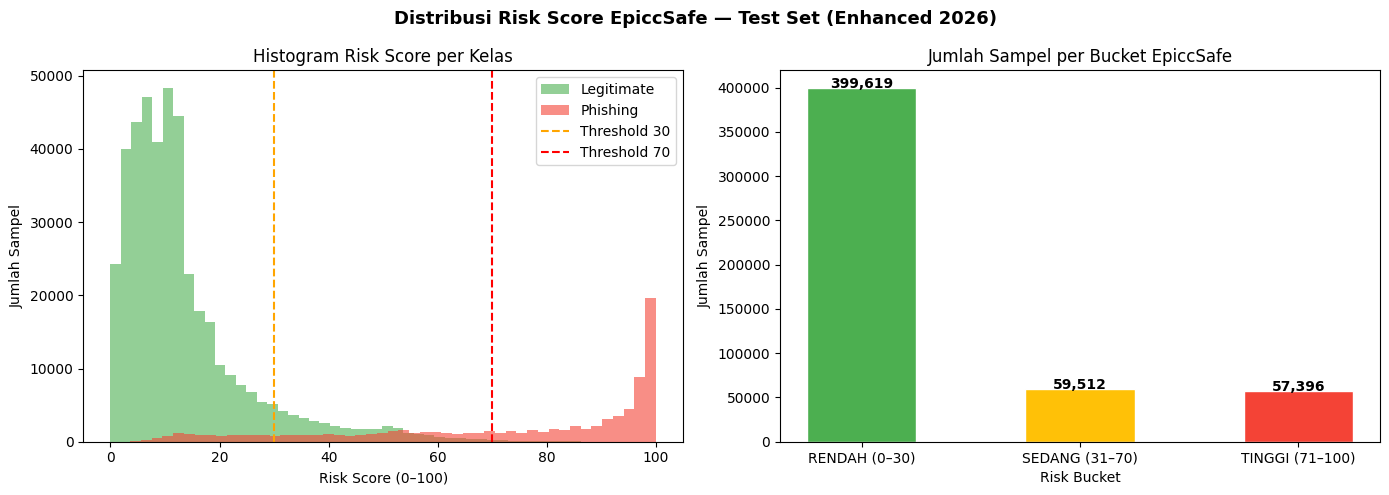


[✓] Visualisasi disimpan: distribusi_risk_score.png


In [34]:
# ============================================================
# EVALUASI — Distribusi Risk Score pada Test Set (Enhanced 2026)
# ============================================================

# Hitung probabilitas phishing untuk setiap sampel di X_final
proba_final = rf_model_combined.predict_proba(X_final)[:, 1]
risk_scores_final = proba_final * 100

# Klasifikasi ke dalam bucket threshold EpiccSafe
def klasifikasi_threshold(score):
    if score <= 30:
        return "RENDAH (0–30)"
    elif score <= 70:
        return "SEDANG (31–70)"
    else:
        return "TINGGI (71–100)"

risk_labels_final = [klasifikasi_threshold(s) for s in risk_scores_final]

df_eval = pd.DataFrame({
    "true_label"  : y_final.values,
    "risk_score"  : risk_scores_final,
    "risk_bucket" : risk_labels_final,
    "pred_label"  : y_final_pred_combined,
})

# Ringkasan distribusi bucket
print("=" * 55)
print("DISTRIBUSI RISK SCORE — Test Set (Enhanced 2026)")
print("=" * 55)
bucket_counts = df_eval["risk_bucket"].value_counts().reindex(
    ["RENDAH (0–30)", "SEDANG (31–70)", "TINGGI (71–100)"], fill_value=0
)
for bucket, count in bucket_counts.items():
    pct = count / len(df_eval) * 100
    print(f"  {bucket:<20}: {count:>6,} sampel  ({pct:.1f}%)")
print(f"  {'TOTAL':<20}: {len(df_eval):>6,} sampel")

# Breakdown per bucket × true label
print("\n" + "-" * 55)
print("BREAKDOWN BUCKET × TRUE LABEL")
print("-" * 55)
ct = pd.crosstab(df_eval["risk_bucket"], df_eval["true_label"],
                 rownames=["Bucket"], colnames=["True Label"])
ct.columns = ["Legitimate (0)", "Phishing (1)"]
print(ct.to_string())

# Visualisasi distribusi risk score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribusi Risk Score EpiccSafe — Test Set (Enhanced 2026)",
             fontsize=13, fontweight="bold")

# Plot 1: Histogram risk score dipisah per label
colors_map = {0: "#4CAF50", 1: "#F44336"}
for lbl, grp in df_eval.groupby("true_label"):
    axes[0].hist(grp["risk_score"], bins=50, alpha=0.6,
                 color=colors_map[lbl],
                 label="Legitimate" if lbl == 0 else "Phishing")
axes[0].axvline(30, color="orange", linestyle="--", linewidth=1.5, label="Threshold 30")
axes[0].axvline(70, color="red",    linestyle="--", linewidth=1.5, label="Threshold 70")
axes[0].set_title("Histogram Risk Score per Kelas")
axes[0].set_xlabel("Risk Score (0–100)")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].legend()

# Plot 2: Bar chart distribusi bucket
bucket_order  = ["RENDAH (0–30)", "SEDANG (31–70)", "TINGGI (71–100)"]
bucket_colors = ["#4CAF50", "#FFC107", "#F44336"]
counts = [bucket_counts.get(b, 0) for b in bucket_order]
bars = axes[1].bar(bucket_order, counts, color=bucket_colors, edgecolor="white", width=0.5)
axes[1].set_title("Jumlah Sampel per Bucket EpiccSafe")
axes[1].set_ylabel("Jumlah Sampel")
axes[1].set_xlabel("Risk Bucket")
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{cnt:,}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("distribusi_risk_score.png", dpi=130, bbox_inches="tight")
plt.show()
print("\n[✓] Visualisasi disimpan: distribusi_risk_score.png")


### Evaluasi Metrik per Bucket EpiccSafe

In [35]:
# ============================================================
# EVALUASI METRIK PER BUCKET — Precision, Recall, F1
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("=" * 65)
print("METRIK EVALUASI KESELURUHAN — Model RF Gabungan (Enhanced 2026)")
print("=" * 65)

overall_acc  = accuracy_score(y_final, y_final_pred_combined)
overall_roc  = roc_auc_score(y_final, y_final_pred_proba_combined)
overall_prec = precision_score(y_final, y_final_pred_combined)
overall_rec  = recall_score(y_final, y_final_pred_combined)
overall_f1   = f1_score(y_final, y_final_pred_combined)

print(f"  Accuracy  : {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"  ROC-AUC   : {overall_roc:.4f}")
print(f"  Precision : {overall_prec:.4f}  (dari semua yang diprediksi Phishing, berapa % benar?)")
print(f"  Recall    : {overall_rec:.4f}  (dari semua Phishing nyata, berapa % terdeteksi?)")
print(f"  F1-Score  : {overall_f1:.4f}")

# Evaluasi per Risk Bucket EpiccSafe
print("\n" + "=" * 65)
print("EVALUASI METRIK PER BUCKET EpiccSafe")
print("=" * 65)
bucket_order = ["RENDAH (0–30)", "SEDANG (31–70)", "TINGGI (71–100)"]
bucket_icons = {"RENDAH (0–30)": "🟢", "SEDANG (31–70)": "🟡", "TINGGI (71–100)": "🔴"}

rows = []
for bucket in bucket_order:
    subset = df_eval[df_eval["risk_bucket"] == bucket]
    if len(subset) == 0:
        continue
    n_total    = len(subset)
    n_phishing = (subset["true_label"] == 1).sum()
    n_legit    = (subset["true_label"] == 0).sum()
    pct_phish  = n_phishing / n_total * 100

    icon = bucket_icons[bucket]
    print(f"\n{icon}  {bucket}")
    print(f"   Total sampel   : {n_total:,}")
    print(f"   Legitimate (0) : {n_legit:,}  ({n_legit/n_total*100:.1f}%)")
    print(f"   Phishing   (1) : {n_phishing:,}  ({pct_phish:.1f}%)")
    if n_total >= 2 and len(subset["true_label"].unique()) > 1:
        acc_b  = accuracy_score(subset["true_label"], subset["pred_label"])
        prec_b = precision_score(subset["true_label"], subset["pred_label"], zero_division=0)
        rec_b  = recall_score(subset["true_label"], subset["pred_label"], zero_division=0)
        f1_b   = f1_score(subset["true_label"], subset["pred_label"], zero_division=0)
        print(f"   Accuracy       : {acc_b:.4f}")
        print(f"   Precision      : {prec_b:.4f}")
        print(f"   Recall         : {rec_b:.4f}")
        print(f"   F1-Score       : {f1_b:.4f}")
        rows.append({"Bucket": bucket, "Total": n_total, "Phishing%": round(pct_phish,1),
                     "Accuracy": round(acc_b,4), "Precision": round(prec_b,4),
                     "Recall": round(rec_b,4), "F1": round(f1_b,4)})
    else:
        print("   (tidak cukup variasi label untuk menghitung metrik per bucket)")

print("\n" + "=" * 65)
print("RINGKASAN TABEL METRIK PER BUCKET")
print("=" * 65)
if rows:
    df_metrik = pd.DataFrame(rows)
    print(df_metrik.to_string(index=False))


METRIK EVALUASI KESELURUHAN — Model RF Gabungan (Enhanced 2026)
  Accuracy  : 0.9411  (94.11%)
  ROC-AUC   : 0.9624
  Precision : 0.8683  (dari semua yang diprediksi Phishing, berapa % benar?)
  Recall    : 0.7763  (dari semua Phishing nyata, berapa % terdeteksi?)
  F1-Score  : 0.8197

EVALUASI METRIK PER BUCKET EpiccSafe

🟢  RENDAH (0–30)
   Total sampel   : 399,619
   Legitimate (0) : 389,121  (97.4%)
   Phishing   (1) : 10,498  (2.6%)
   Accuracy       : 0.9737
   Precision      : 0.0000
   Recall         : 0.0000
   F1-Score       : 0.0000

🟡  SEDANG (31–70)
   Total sampel   : 59,512
   Legitimate (0) : 37,259  (62.6%)
   Phishing   (1) : 22,253  (37.4%)
   Accuracy       : 0.6819
   Precision      : 0.5745
   Recall         : 0.5757
   F1-Score       : 0.5751

🔴  TINGGI (71–100)
   Total sampel   : 57,396
   Legitimate (0) : 1,006  (1.8%)
   Phishing   (1) : 56,390  (98.2%)
   Accuracy       : 0.9825
   Precision      : 0.9825
   Recall         : 1.0000
   F1-Score       : 0.9912

### Evaluasi ROC Curve & Boxplot Risk Score

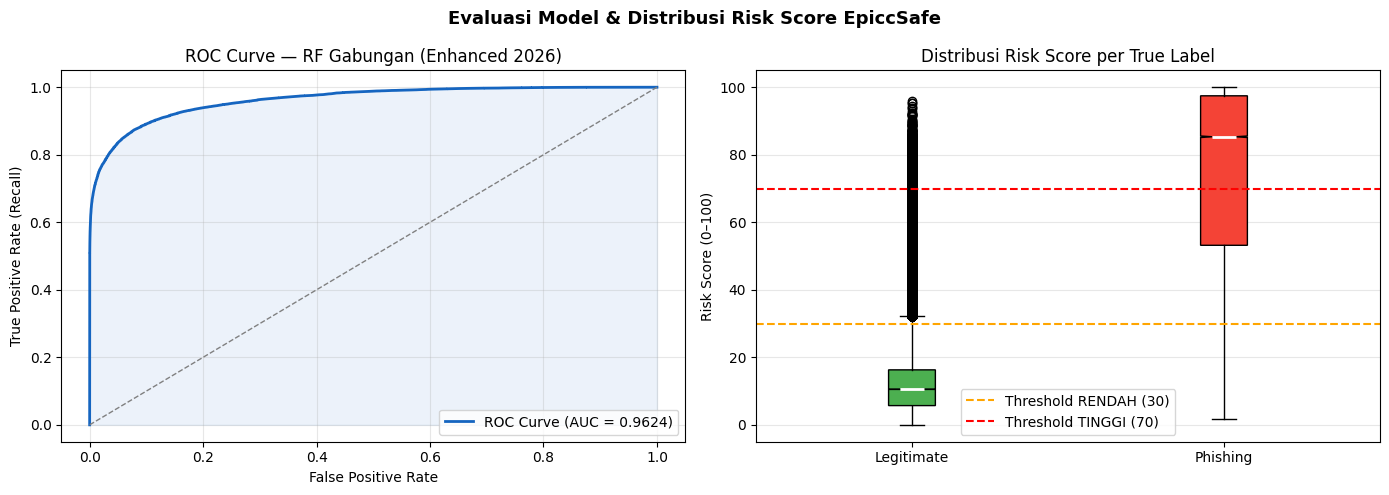

[✓] Visualisasi disimpan: roc_dan_boxplot_riskscore.png

RINGKASAN SISTEM RISK SCORING EPICCSAFE
  Model            : Random Forest Gabungan
  Accuracy         : 94.11%
  ROC-AUC          : 0.9624
  Total URL diuji  : 516,527

  🟢  RENDAH (0–30)       : 399,619 URL  (77.4%)
  🟡  SEDANG (31–70)      : 59,512 URL  (11.5%)
  🔴  TINGGI (71–100)     : 57,396 URL  (11.1%)

✅ Risk Scoring EpiccSafe selesai diimplementasikan!


In [36]:
# ============================================================
# VISUALISASI — ROC Curve & Risk Score Distribution Boxplot
# ============================================================
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluasi Model & Distribusi Risk Score EpiccSafe",
             fontsize=13, fontweight="bold")

# ── Plot 1: ROC Curve ────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_final, y_final_pred_proba_combined)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="#1565C0", lw=2,
             label=f"ROC Curve (AUC = {roc_auc_val:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#1565C0")
axes[0].set_title("ROC Curve — RF Gabungan (Enhanced 2026)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# ── Plot 2: Boxplot Risk Score per True Label ─────────────────
data_legit   = df_eval[df_eval["true_label"] == 0]["risk_score"]
data_phish   = df_eval[df_eval["true_label"] == 1]["risk_score"]
bp = axes[1].boxplot([data_legit, data_phish],
                     labels=["Legitimate", "Phishing"],
                     patch_artist=True, notch=True,
                     medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor("#4CAF50")
bp["boxes"][1].set_facecolor("#F44336")
axes[1].axhline(30, color="orange", linestyle="--", linewidth=1.5, label="Threshold RENDAH (30)")
axes[1].axhline(70, color="red",    linestyle="--", linewidth=1.5, label="Threshold TINGGI (70)")
axes[1].set_title("Distribusi Risk Score per True Label")
axes[1].set_ylabel("Risk Score (0–100)")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("roc_dan_boxplot_riskscore.png", dpi=130, bbox_inches="tight")
plt.show()
print("[✓] Visualisasi disimpan: roc_dan_boxplot_riskscore.png")

# Ringkasan akhir
print("\n" + "=" * 60)
print("RINGKASAN SISTEM RISK SCORING EPICCSAFE")
print("=" * 60)
print(f"  Model            : Random Forest Gabungan")
print(f"  Accuracy         : {overall_acc*100:.2f}%")
print(f"  ROC-AUC          : {overall_roc:.4f}")
print(f"  Total URL diuji  : {len(df_eval):,}")
print()
for bucket in bucket_order:
    cnt = bucket_counts.get(bucket, 0)
    pct = cnt / len(df_eval) * 100
    icon = bucket_icons[bucket]
    print(f"  {icon}  {bucket:<20}: {cnt:>6,} URL  ({pct:.1f}%)")
print("=" * 60)
print("\n✅ Risk Scoring EpiccSafe selesai diimplementasikan!")

### Simpan Model Gabungan untuk Deployment

In [37]:
# ============================================================
# SIMPAN MODEL GABUNGAN (rf_model_combined)
# ============================================================
import joblib

joblib.dump(rf_model_combined, "rf_model_combined_epiccsafe.pkl")
print("[✓] Model gabungan disimpan: rf_model_combined_epiccsafe.pkl")
print("[!] Gunakan file ini bersama scaler_epiccsafe.pkl untuk deployment EpiccSafe.")


[✓] Model gabungan disimpan: rf_model_combined_epiccsafe.pkl
[!] Gunakan file ini bersama scaler_epiccsafe.pkl untuk deployment EpiccSafe.
